<h1>Train — ResNet-50</h1>

Trains and evaluates ResNet-50 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet50"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet50"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-50: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-50: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-50)
# ---------------------------------------------------------
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-50] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


[ResNet-50] Epoch   1/100 | LR: 4.06e-04 | train loss 1.0595 acc 0.556 | val loss 0.7663 acc 0.665 *


[ResNet-50] Epoch   2/100 | LR: 4.06e-04 | train loss 0.7916 acc 0.721 | val loss 0.4650 acc 0.806 *


[ResNet-50] Epoch   3/100 | LR: 4.06e-04 | train loss 0.7110 acc 0.738 | val loss 0.7747 acc 0.659


[ResNet-50] Epoch   4/100 | LR: 4.06e-04 | train loss 0.6467 acc 0.776 | val loss 0.5520 acc 0.735


...

[ResNet-50] Epoch   8/100 | LR: 4.06e-04 | train loss 0.5281 acc 0.836 | val loss 0.5556 acc 0.735


[ResNet-50] Epoch   9/100 | LR: 4.06e-04 | train loss 0.4102 acc 0.843 | val loss 1.0925 acc 0.588


[ResNet-50] Epoch  10/100 | LR: 4.06e-04 | train loss 0.4663 acc 0.846 | val loss 0.6537 acc 0.729


[ResNet-50] Epoch  11/100 | LR: 4.06e-04 | train loss 0.3811 acc 0.853 | val loss 0.5127 acc 0.806


[ResNet-50] Epoch  12/100 | LR: 4.06e-04 | train loss 0.3723 acc 0.882 | val loss 0.5143 acc 0.812

[ResNet-50] No val loss improvement for 10 epochs — stopping early at epoch 12.

[ResNet-50] Restored best checkpoint (val loss = 0.4650)


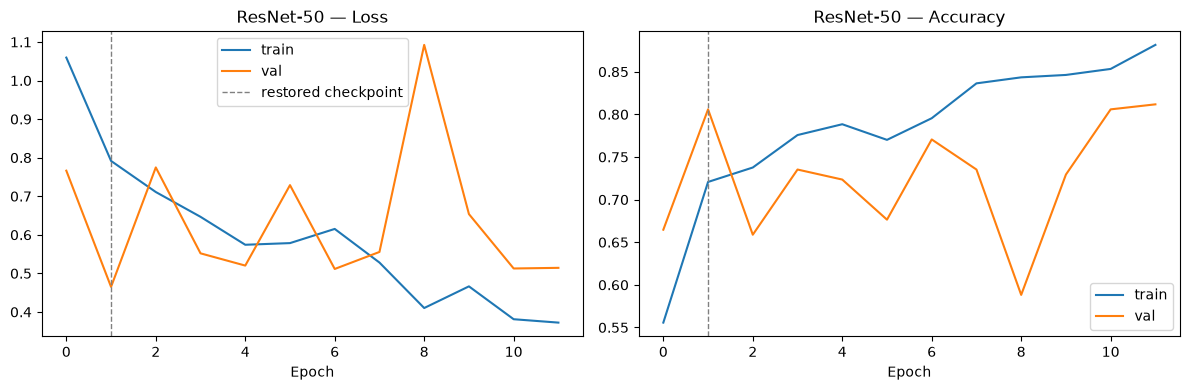

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-50", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-50")

## Evaluate on the test set

[ResNet-50] Test accuracy: 0.578


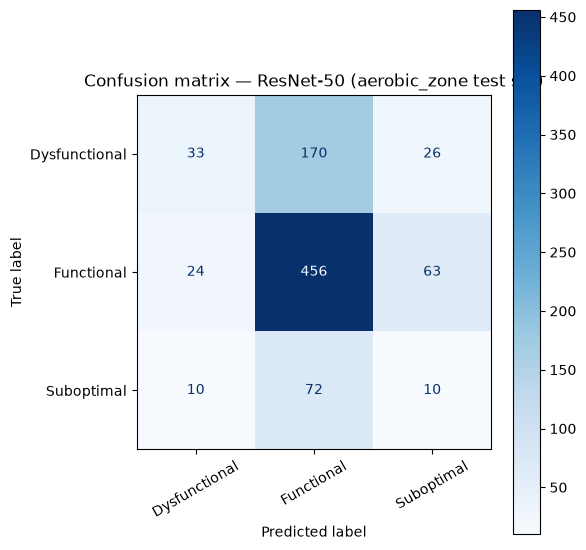

               precision    recall  f1-score   support

Dysfunctional      0.493     0.144     0.223       229
   Functional      0.653     0.840     0.735       543
   Suboptimal      0.101     0.109     0.105        92

     accuracy                          0.578       864
    macro avg      0.416     0.364     0.354       864
 weighted avg      0.552     0.578     0.532       864



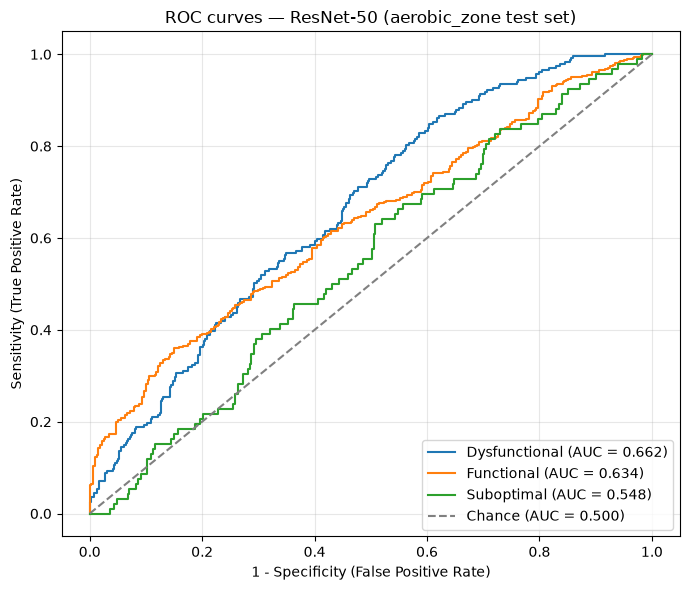

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.662
  Functional     : 0.634
  Suboptimal     : 0.548

Mean AUC (over 3/3 classes with test examples): 0.614


(np.float64(0.5775462962962963),
 {'Dysfunctional': 0.6617130282295499,
  'Functional': 0.6336494495218097,
  'Suboptimal': 0.5479133813922055})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-50", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ResNet-50", "resnet50")

Saved results to ../results/aerobic_zone_aug/results_aerobic_zone_resnet50_Waterval.pkl
Saved model weights to ../models/aerobic_zone_resnet50_cnn.pt
